# 03 Feature Engineering & SMOTE Ablation Study

## Objective

This notebook investigates whether **domain-driven feature engineering** and **class imbalance handling (SMOTE)** improve supervised learning performance.

To avoid redundant data loading and result exporting, all related experiments are conducted within a single notebook while keeping **experimental variables clearly isolated**.

---

## Experimental Design

We fix the **model choice** based on previous experiments:

* **Classifier**: K-Nearest Neighbors (KNN)

We evaluate four controlled settings:

| Experiment   | Feature Engineering | SMOTE |
| ------------ | ------------------- | ----- |
| A (Baseline) | ❌                   | ❌     |
| B            | ✅                   | ❌     |
| C            | ❌                   | ✅     |
| D            | ✅                   | ✅     |

This structure enables an **ablation study** to disentangle the individual and combined effects of feature engineering and SMOTE.

---

## 1. Data Loading and Preprocessing

### 1.1 Load Dataset


In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


from imblearn.over_sampling import SMOTE

df = pd.read_csv("../data/diabetes_processed.csv")

## 1.2 Train–Test Split

In [2]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Baseline Model (Experiment A)
## 2.1 Scaling

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2.2 train KNN

In [4]:
knn = KNeighborsClassifier(n_neighbors=15, weights="uniform", metric="euclidean")
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [5]:

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]


    return {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
    }

results = {}
results["A_baseline"] = evaluate_model(knn, X_test_scaled, y_test)

# . Domain-Driven Feature Engineering
## 3.1 Feature Construction Rationale

We construct composite features to reduce dimensionality and encode higher-level behavioral and socioeconomic patterns:

Lifestyle Risk: physical activity, smoking, alcohol consumption, Fruits, Veggies

Socioeconomic & Access: income, NoDocbcCost, AnyHealthcare

Health Burden: PhysHlth, MentHlth, DiffWalk

## 3.2 Feature Construction

In [6]:
df_fe = df.copy()

df_fe["Lifestyle_Risk_Score"] = (
    df_fe["HvyAlcoholConsump"]
    + df_fe["Smoker"]
    + (1 - df_fe["PhysActivity"])
    + (1 - df_fe["Fruits"])
    + (1 - df_fe["Veggies"])
)

from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
df_fe[["Income_z", "Education_z"]] = scaler.fit_transform(df_fe[["Income", "Education"]] )
df_fe[["PhysHlth_z", "MentHlth_z"]] = scaler.fit_transform( df_fe[["PhysHlth", "MentHlth"]] )

df_fe["Health_Burden_Score"] = ( df_fe["PhysHlth_z"] + df_fe["MentHlth_z"] + df_fe["DiffWalk"] )
df_fe["Socioeconomic_Access_Score"] = ( df_fe["Income_z"] + df_fe["Education_z"] + df_fe["AnyHealthcare"] + df_fe["NoDocbcCost"] )

B_features = [ "BMI", "Age", "HighBP", "HighChol", "Health_Burden_Score", "Lifestyle_Risk_Score", "Socioeconomic_Access_Score", "Sex" ]
drop_cols = [ "HvyAlcoholConsump", "Smoker", "PhysActivity", 
             "Fruits", "Veggies", "Income", "Education", "AnyHealthcare", 
             "NoDocbcCost", "PhysHlth", "MentHlth", "DiffWalk", "Stroke", "Diabetes_binary", "Stroke", "HeartDiseaseorAttack" ] 

X_fe = df_fe.drop(columns=drop_cols)
y_fe = df_fe["Diabetes_binary"]


X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
X_fe, y_fe, test_size=0.2, stratify=y_fe, random_state=42
)

## 4. Feature Engineering Only (Experiment B)

In [7]:
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)


knn_fe = KNeighborsClassifier(n_neighbors=15, weights="uniform", metric="euclidean")
knn_fe.fit(X_train_fe_scaled, y_train_fe)


results["B_feature_engineering"] = evaluate_model(
knn_fe, X_test_fe_scaled, y_test_fe
)

# 5. SMOTE Experiments
## 5.1 SMOTE without Feature Engineering (Experiment C)

In [8]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

knn_sm = KNeighborsClassifier(n_neighbors=15,  weights="uniform", metric="euclidean")
knn_sm.fit(X_train_sm, y_train_sm)

results["C_smote_only"] = evaluate_model(knn_sm, X_test_scaled, y_test)

## 5.2 SMOTE with Feature Engineering (Experiment D)

In [12]:
X_train_fe_sm, y_train_fe_sm = smote.fit_resample(
X_train_fe_scaled, y_train_fe
)


knn_fe_sm = KNeighborsClassifier(n_neighbors=15,  weights="uniform", metric="euclidean")
knn_fe_sm.fit(X_train_fe_sm, y_train_fe_sm)


results["D_feature_engineering_smote"] = evaluate_model(
knn_fe_sm, X_test_fe_scaled, y_test_fe
)

# 6. Results Comparison

In [13]:
results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,roc_auc
A_baseline,0.843405,0.509071,0.175485,0.260999,0.779193
B_feature_engineering,0.844450,0.516512,0.201501,0.289905,0.781938
C_smote_only,0.686928,0.299538,0.737211,0.425990,0.768127
D_feature_engineering_smote,0.693827,0.302219,0.720450,0.425815,0.768025


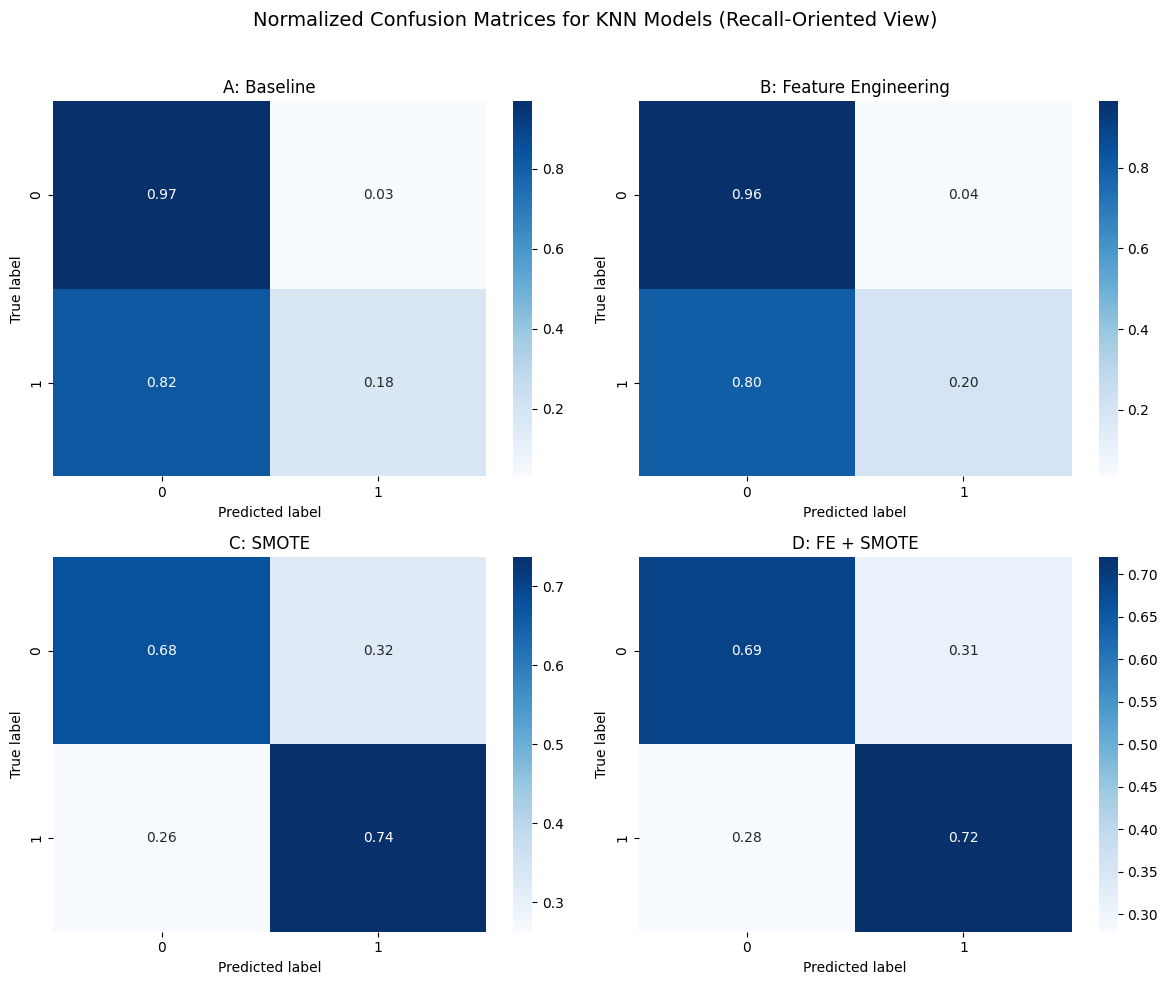

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "A: Baseline": (knn, X_test_scaled, y_test),
    "B: Feature Engineering": (knn_fe, X_test_fe_scaled, y_test_fe),
    "C: SMOTE": (knn_sm, X_test_scaled, y_test),
    "D: FE + SMOTE": (knn_fe_sm, X_test_fe_scaled, y_test_fe)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, (model, X_t, y_t)) in zip(axes, models.items()):
    y_pred = model.predict(X_t)
    cm = confusion_matrix(y_t, y_pred, normalize="true")

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Normalized Confusion Matrices for KNN Models (Recall-Oriented View)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 7. Discussion
Although SMOTE slightly reduces overall accuracy, it significantly lowers the false negative rate, which is critical for imbalanced classification tasks. Therefore, the SMOTE-based KNN model is selected as the final model due to its superior ability to identify minority-class instances.
The changes brought by FE are not obvious and have been somewhat inconsistent. To be on the safe side, it is not adopted.